In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:

data = dict()

combined_df = pd.DataFrame()
for i in [1,2,5,10]:
    df = pd.read_csv(f'../Assets/Data/Milestone1/crowd_metrics_{i}k.csv')
    combined_df = pd.concat([combined_df, df], ignore_index=True)
    data[i] = {
        'avg_fps': df['average_fps'].mean(),
        'avg_dt': df['average_delta_time_ms'].mean(),
    }
    task_changes = df['completed_tasks'].diff().tolist()[1:]
    time_changes = df['time_seconds'].diff().tolist()[1:]
    data[i]['task_completion_rate'] = np.mean([task_changes[j] / (i*1000.0) / time_changes[j] for j in range(len(task_changes)) if time_changes[j] > 0])
print(data)

{1: {'avg_fps': np.float64(77.07666666666667), 'avg_dt': np.float64(12.979666666666667), 'task_completion_rate': np.float64(0.0375241113018258)}, 2: {'avg_fps': np.float64(43.75666666666666), 'avg_dt': np.float64(22.861666666666665), 'task_completion_rate': np.float64(0.023661006760281975)}, 5: {'avg_fps': np.float64(18.80333333333333), 'avg_dt': np.float64(53.197333333333326), 'task_completion_rate': np.float64(0.007047083801434512)}, 10: {'avg_fps': np.float64(9.493333333333334), 'avg_dt': np.float64(105.33433333333333), 'task_completion_rate': np.float64(0.0030138317275661174)}}


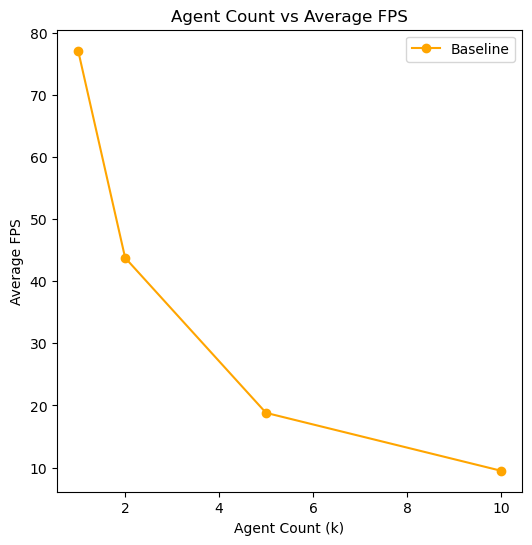

In [3]:
plt.figure(figsize=(6, 6))
plt.plot(list(data.keys()), [data[i]['avg_fps'] for i in data], label='Baseline', color='orange', marker='o')
plt.xlabel('Agent Count (k)')
plt.ylabel('Average FPS')
plt.title('Agent Count vs Average FPS')
plt.legend()
plt.show()

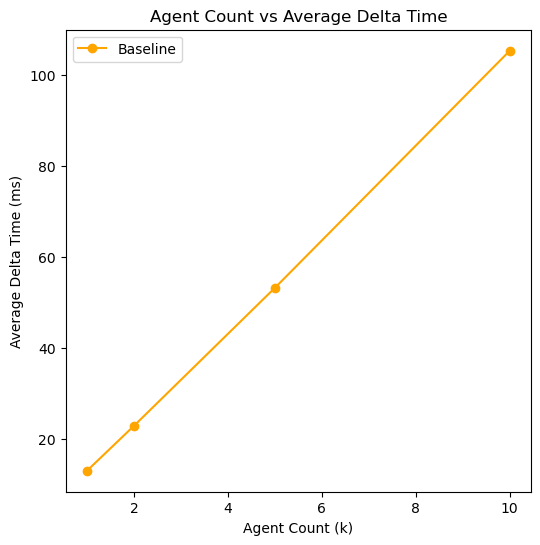

In [4]:
plt.figure(figsize=(6, 6))
plt.plot(list(data.keys()), [data[i]['avg_dt'] for i in data], label='Baseline', color='orange', marker='o')
plt.xlabel('Agent Count (k)')
plt.ylabel('Average Delta Time (ms)')
plt.title('Agent Count vs Average Delta Time')
plt.legend()
plt.show()

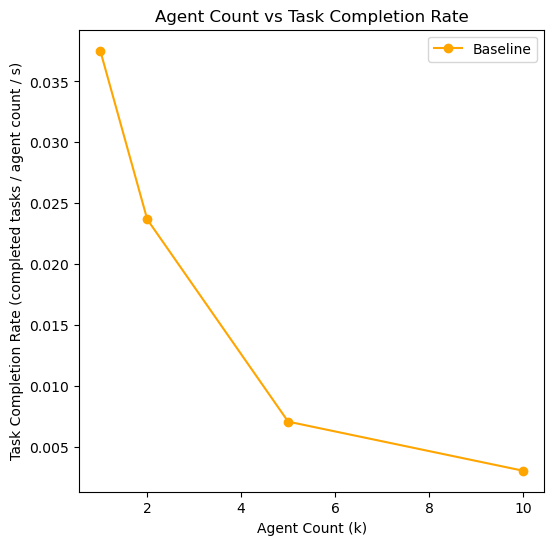

In [5]:
# plot the task completion rate as a function of agent count
plt.figure(figsize=(6, 6))
plt.plot(list(data.keys()), [data[i]['task_completion_rate'] for i in data], label='Baseline', color='orange', marker='o')
plt.xlabel('Agent Count (k)')
plt.ylabel('Task Completion Rate (completed tasks / agent count / s)')
plt.title('Agent Count vs Task Completion Rate')
plt.legend()
plt.show()